# New SectionTrain a simple convnet on the Fashion MNIST dataset¶

In [0]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

Load the  fashion_mnist dataset

In [24]:
# Further break training data into train / validation sets (# put 5000 into validation set and keep remaining 55,000 for train)
#(x_train, x_valid) = x_train[5000:], x_train[:5000] 
#(y_train, y_valid) = y_train[5000:], y_train[:5000]

# Reshape input data from (28, 28) to (28, 28, 1)
w, h = 28, 28
x_train = x_train.reshape(x_train.shape[0], w, h, 1)
#x_valid = x_valid.reshape(x_valid.shape[0], w, h, 1)
x_test = x_test.reshape(x_test.shape[0], w, h, 1)

# One-hot encode the labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
#y_valid = tf.keras.utils.to_categorical(y_valid, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Print training set shape
print("x_train shape:", x_train.shape, "y_train shape:", y_train.shape)

# Print the number of training, validation, and test datasets
print(x_train.shape[0], 'train set')
#print(x_valid.shape[0], 'validation set')
print(x_test.shape[0], 'test set')

x_train shape: (60000, 28, 28, 1) y_train shape: (60000, 10)
60000 train set
10000 test set


Find no.of samples are there in training and test datasets

In [25]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
# Load the fashion-mnist pre-shuffled train data and test data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
print("x_train shape:", x_train.shape, "y_train shape:", y_train.shape)

x_train shape: (60000, 28, 28) y_train shape: (60000,)


In [0]:
w, h = 28, 28
x_train = x_train.reshape(x_train.shape[0], w, h, 1)
x_test = x_test.reshape(x_test.shape[0], w, h, 1)

In [27]:
x_train.shape
x_test.shape
print("x_train shape:", x_train.shape, "y_train shape:", y_train.shape)

x_train shape: (60000, 28, 28, 1) y_train shape: (60000,)


Find dimensions of an image in the dataset

In [28]:
y=x_train[5].reshape(28,28)
y.shape

(28, 28)

x_train shape: (60000, 28, 28, 1) y_train shape: (60000,)
60000 train set
10000 test set
y = 2 Pullover


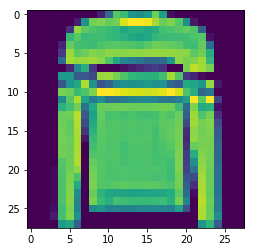

In [29]:
# Print training set shape - note there are 60,000 training data of image size of 28x28, 60,000 train labels)
print("x_train shape:", x_train.shape, "y_train shape:", y_train.shape)

# Print the number of training and test datasets
print(x_train.shape[0], 'train set')
print(x_test.shape[0], 'test set')

# Define the text labels
fashion_mnist_labels = ["T-shirt/top",  # index 0
                        "Trouser",      # index 1
                        "Pullover",     # index 2 
                        "Dress",        # index 3 
                        "Coat",         # index 4
                        "Sandal",       # index 5
                        "Shirt",        # index 6 
                        "Sneaker",      # index 7 
                        "Bag",          # index 8 
                        "Ankle boot"]   # index 9

# Image index, you can pick any number between 0 and 59,999
img_index = 5
# y_train contains the lables, ranging from 0 to 9
label_index = y_train[img_index]
# Print the label, for example 2 Pullover
print ("y = " + str(label_index) + " " +(fashion_mnist_labels[label_index]))
# # Show one of the images from the training dataset
plt.imshow(y)

In [0]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [0]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [32]:
print("Number of train data - " + str(len(x_train)))
print("Number of test data - " + str(len(x_test)))

Number of train data - 60000
Number of test data - 10000


In [0]:
import keras
from keras.layers import Conv2D, MaxPool2D, Flatten
from keras.layers import Dense, Dropout
model = tf.keras.Sequential()
# Must define the input shape in the first layer of the neural network
model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(28,28,1))) 

In [0]:
import keras
from keras.layers import Conv2D, MaxPool2D, Flatten
from keras.layers import Dense, Dropout

#import mnist_reader

In [35]:
model = tf.keras.Sequential()

# Must define the input shape in the first layer of the neural network
model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(28,28,1))) 
#model.add(tf.keras.layers.MaxPooling2D(pool_size=1))
model.add(tf.keras.layers.Dropout(0))

model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'))
#model.add(tf.keras.layers.MaxPooling2D(pool_size=1))
model.add(tf.keras.layers.Dropout(0))

model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dropout(0))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

# Take a look at the model summary
model.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_6 (Conv2D)            (None, 28, 28, 32)        320       
_________________________________________________________________
dropout_6 (Dropout)          (None, 28, 28, 32)        0         
_________________________________________________________________
conv2d_7 (Conv2D)            (None, 28, 28, 32)        9248      
_________________________________________________________________
dropout_7 (Dropout)          (None, 28, 28, 32)        0         
_________________________________________________________________
flatten_2 (Flatten)          (None, 25088)             0         
_________________________________________________________________
dense_4 (Dense)              (None, 256)               6422784   
_________________________________________________________________
dropout_8 (Dropout)          (None, 256)              

In [36]:
model = tf.keras.Sequential()

# Must define the input shape in the first layer of the neural network
model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=2, padding='same', activation='relu', input_shape=(28,28,1))) 
model.add(tf.keras.layers.MaxPooling2D(pool_size=2))
model.add(tf.keras.layers.Dropout(0))

model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=2, padding='same', activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=2))
model.add(tf.keras.layers.Dropout(0))

model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dropout(0.25))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

# Take a look at the model summary
model.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_8 (Conv2D)            (None, 28, 28, 32)        160       
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 14, 14, 32)        0         
_________________________________________________________________
dropout_9 (Dropout)          (None, 14, 14, 32)        0         
_________________________________________________________________
conv2d_9 (Conv2D)            (None, 14, 14, 32)        4128      
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 7, 7, 32)          0         
_________________________________________________________________
dropout_10 (Dropout)         (None, 7, 7, 32)          0         
_________________________________________________________________
flatten_3 (Flatten)          (None, 1568)             

In [0]:
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
from keras.callbacks import ModelCheckpoint

checkpointer = ModelCheckpoint(filepath='model.weights.best.hdf5', verbose = 1, save_best_only=True)

In [38]:
model.fit(x_train,
         y_train,
         epochs=10) 

Epoch 1/10
60000/60000 [==============================] - 52s 863us/sample - loss: 0.4347 - acc: 0.8422
Epoch 2/10
60000/60000 [==============================] - 52s 866us/sample - loss: 0.2964 - acc: 0.8920
Epoch 3/10
60000/60000 [==============================] - 52s 867us/sample - loss: 0.2602 - acc: 0.9030
Epoch 4/10
60000/60000 [==============================] - 53s 879us/sample - loss: 0.2319 - acc: 0.9134
Epoch 5/10
60000/60000 [==============================] - 52s 867us/sample - loss: 0.2095 - acc: 0.9217
Epoch 6/10
60000/60000 [==============================] - 52s 864us/sample - loss: 0.1894 - acc: 0.9301
Epoch 7/10
60000/60000 [==============================] - 52s 869us/sample - loss: 0.1740 - acc: 0.9342
Epoch 8/10
60000/60000 [==============================] - 52s 872us/sample - loss: 0.1583 - acc: 0.9406
Epoch 9/10
60000/60000 [==============================] - 52s 866us/sample - loss: 0.1460 - acc: 0.9456
Epoch 10/10
60000/60000 [==============================] - 52s 8

In [39]:
model.fit(x_train,
         y_train,
         validation_data=(x_test,y_test), 
         batch_size=32,
         epochs=10)

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 55s 911us/sample - loss: 0.1193 - acc: 0.9550 - val_loss: 0.2638 - val_acc: 0.9216
Epoch 2/10
60000/60000 [==============================] - 55s 915us/sample - loss: 0.1095 - acc: 0.9595 - val_loss: 0.2575 - val_acc: 0.9195
Epoch 3/10
60000/60000 [==============================] - 55s 909us/sample - loss: 0.0994 - acc: 0.9623 - val_loss: 0.2979 - val_acc: 0.9172
Epoch 4/10
60000/60000 [==============================] - 55s 917us/sample - loss: 0.0921 - acc: 0.9653 - val_loss: 0.3042 - val_acc: 0.9178
Epoch 5/10
60000/60000 [==============================] - 55s 920us/sample - loss: 0.0820 - acc: 0.9691 - val_loss: 0.3070 - val_acc: 0.9211
Epoch 6/10
60000/60000 [==============================] - 54s 906us/sample - loss: 0.0768 - acc: 0.9711 - val_loss: 0.3267 - val_acc: 0.9096
Epoch 7/10
60000/60000 [==============================] - 55s 910us/sample - loss: 0.0706 - acc: 0.9736 

In [0]:
import keras
from keras.preprocessing.image import ImageDataGenerator
keras.preprocessing.image.ImageDataGenerator(featurewise_center=False, samplewise_center=False, featurewise_std_normalization=False, samplewise_std_normalization=False, zca_whitening=False, zca_epsilon=1e-06, rotation_range=0, width_shift_range=0.0, height_shift_range=0.0, brightness_range=None, shear_range=0.0, zoom_range=0.0, channel_shift_range=0.0, fill_mode='nearest', cval=0.0, horizontal_flip=False, vertical_flip=False, rescale=None, preprocessing_function=None, data_format=None, validation_split=0.0, dtype=None)
datagen = ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True)

In [0]:
# compute quantities required for featurewise normalization
# (std, mean, and principal components if ZCA whitening is applied)
datagen.fit(x_train)

In [47]:
# fits the model on batches with real-time data augmentation:
model.fit_generator(datagen.flow(x_train, y_train, batch_size=32),
                    steps_per_epoch=len(x_train) / 32,
                    validation_data=(x_test,y_test), 
                    epochs=10)

Epoch 1/10
1875/1875 [==============================] - 67s 36ms/step - loss: 0.4976 - acc: 0.8183 - val_loss: 14.6385 - val_acc: 0.1612
Epoch 2/10
1875/1875 [==============================] - 67s 36ms/step - loss: 0.4888 - acc: 0.8217 - val_loss: 18.7628 - val_acc: 0.1492
Epoch 3/10
1875/1875 [==============================] - 67s 36ms/step - loss: 0.4765 - acc: 0.8245 - val_loss: 18.3088 - val_acc: 0.1319
Epoch 4/10
1875/1875 [==============================] - 66s 35ms/step - loss: 0.4712 - acc: 0.8276 - val_loss: 17.7092 - val_acc: 0.1329
Epoch 5/10
1875/1875 [==============================] - 66s 35ms/step - loss: 0.4648 - acc: 0.8301 - val_loss: 17.9914 - val_acc: 0.1367
Epoch 6/10
1875/1875 [==============================] - 67s 35ms/step - loss: 0.4591 - acc: 0.8328 - val_loss: 15.0772 - val_acc: 0.1579
Epoch 7/10
1875/1875 [==============================] - 66s 35ms/step - loss: 0.4498 - acc: 0.8360 - val_loss: 12.9013 - val_acc: 0.1808
Epoch 8/10
1875/1875 [===================

In [0]:
import tensorflow as tf
import numpy as np                                
import matplotlib.pyplot as plt
from tensorflow.examples.tutorials.mnist import input_data
import keras as k
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from keras.optimizers import SGD, Adam
from keras.regularizers import l2
import h5py
from keras.models import load_model
from keras.preprocessing.image import ImageDataGenerator

170500096/170498071 [==============================] - 2s 0us/step


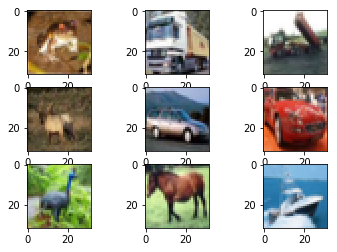

In [49]:
#load data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
img_rows, img_cols , channels= 32,32,3
for i in range(0,9):
    plt.subplot(330 + 1 + i)
    plt.imshow(x_train[i])
plt.show()

In [0]:
# set up image augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
    #zoom_range=0.3
    )
datagen.fit(x_train)

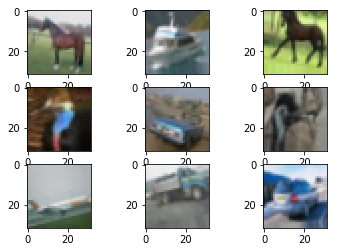

In [51]:
# see example augmentation images
for X_batch, y_batch in datagen.flow(x_train, y_train, batch_size=9):
    for i in range(0, 9):
        plt.subplot(330 + 1 + i)
        plt.imshow(X_batch[i].astype(np.uint8))
    plt.show()
    break

In [52]:

#reshape into images
x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, channels)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, channels)
input_shape = (img_rows, img_cols, 1)
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

x_train shape: (50000, 32, 32, 3)
50000 train samples
10000 test samples


In [0]:
x_train=x_train/255
y_train=y_train/255

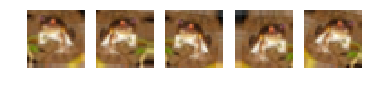

In [55]:
from matplotlib import pyplot as plt
gen = datagen.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()